### PORT INFRASTRUCTURE & CONGESTION ANALYSIS USING SPATIAL DATA

# 1. BUSINESS UNDERSTANDING
## 1.1 Business Overview

Ports are critical nodes in global and regional trade, acting as gateways for imports and exports. In East Africa and the Horn of Africa, ports such as Mombasa (KPA), Dar es Salaam, Djibouti, and Berbera serve as major logistics hubs that support economic activity across multiple landlocked countries.

Efficient port operations depend heavily on surrounding transport infrastructure, particularly road and railway connectivity. Poor connectivity can lead to congestion, delays in cargo movement, increased transport costs, and reduced competitiveness of the port.

With increasing cargo volumes and growing regional trade, it is important to assess how transport infrastructure around ports influences congestion and operational efficiency. Spatial data analysis and machine learning can be used to evaluate connectivity and predict potential delays.

This project applies geospatial analysis and data modeling to evaluate and compare port connectivity and congestion across selected East African and Horn of Africa ports.

## 1.2 Problem Statement

Many ports in East Africa experience congestion and delays due to limited road and rail accessibility. However, there is limited quantitative analysis that links surrounding transport infrastructure to port congestion and delay performance.

Without a structured analysis: It is difficult to compare ports objectively, infrastructure investment decisions are less data-driven, bottlenecks in connectivity remain unidentified

There is a need for a spatial and data-driven framework that evaluates how road and rail infrastructure around ports affects congestion and delay outcomes.

## 1.3 Business Objectives
*Main Objective*

To evaluate and compare port connectivity and congestion in selected East African and regional ports using geospatial analysis and predictive modeling.

*Specific Objectives*

- To measure road network accessibility within a defined buffer distance around each port.

- To measure railway accessibility around each port.

- To develop a connectivity index combining road and rail infrastructure.

- To compare congestion and delay levels across ports.

- To build a predictive model that estimates delay scores based on infrastructure and capacity variables.

- To identify which infrastructure factors most influence port congestion and delays.

*Research Questions*

- How does road network density around a port influence congestion levels?

- Does railway accessibility reduce port delays?

- Which port has the highest overall connectivity index?

- Is there a relationship between connectivity and delay score?

- Which factors best predict congestion and delay at a port?

- How do East African ports compare in terms of infrastructure accessibility?

## 1.4 Success Criteria

The project will be considered successful if it:

- Calculates road and rail accessibility metrics for each port

- Produces a connectivity index for comparison

- Generates spatial visualizations of port infrastructure

- Builds a predictive model for delay score

- Identifies key drivers of congestion

- Provides a clear comparison between ports

- Produces interpretable and reproducible results

# 2. DATA UNDERSTANDING
## 2.1 Data Sources

The project will use:

Spatial Data

Road network shapefiles

Railway network shapefiles

Port coordinates

Operational Data

Trucks per day

Port capacity

Congestion levels

Delay score

## 2.2 Ports Included From Start

We will include all ports from the beginning:

- Mombasa (KPA)

- Dar es Salaam

- Tanga

- Lamu

- Zanzibar

- Djibouti

- Berbera

- Kisumu

- Mwanza


## 2.3 Key Variables

Spatial variables

road_km within 5km

rail_km within 5km

connectivity index

Operational variables

trucks_per_day

capacity

congestion

delay_score

Analyze how infrastructure (roads, rail, connectivity, capacity) affects congestion and delay at major African ports.
Build models to predict:

Regression: delay_score

Classification: congestion level

Ports analyzed are Mombasa, Dar es Salaam

Djibouti

Durban

Data source

OpenStreetMap (via OSMnx)

Engineered infrastructure metrics


In [2]:
!pip install osmnx


  Using cached osmnx-2.0.7-py3-none-any.whl.metadata (4.9 kB)
Using cached osmnx-2.0.7-py3-none-any.whl (101 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB ? eta -:--:--
   -------------------- ------------------- 1.0/2.1 MB 3.9 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.5 MB/s  0:00:00
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   - -------------------------------------- 0.8/22.9 MB 4.2 MB/s eta 0:00:06
   -- ------------------------------------- 1.3/22.9 MB 3.0 MB/s eta 0:00:08
   --- ------------------------------------ 2.1/22.9 MB 3.7 MB/s eta 0:00:06
   ---- ----------------------------------- 2.6/22.9 MB 3.1 MB/s eta 0:00:07
   ----- ---------------------------------- 3.1/22.9 MB 2.9 MB/s eta 0:00:07
   ----- ---------------------------------- 3.4/22.9 MB 2.8 MB/s eta 

In [15]:
!pip install matplotlib


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 5.2 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 8.9 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 8.0 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 8.0 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.6 MB/s  0:00:00

   ---------------------------------------- 0/5 [kiwisolver]
   -------- ------------------------------- 1/5 [fonttools]
   ----

In [18]:
!pip install seaborn

In [19]:
#Define all ports 
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier


# ports and coordinates
ports = {
    "KPA_mombasa": (-4.0435, 39.6682),
    "Dar_es_Salaam": (-6.7924, 39.2083),
    "Tanga": (-5.0696, 39.1023),
    "Lamu": (-2.2717, 40.9020),
    "Zanzibar": (-6.1659, 39.2026),
    "Djibouti": (11.5721, 43.1456),
    "Berbera": (10.4396, 45.0143),
    "Kisumu": (-0.0917, 34.7680),
    "Mwanza": (-2.5164, 32.9175)
    
}


In [20]:
#get roads and rails within 5km
import osmnx as ox
import pandas as pd

def get_port_infrastructure(port_name, lat, lon, radius=5000):

    print(f"Processing {port_name}...")

    # -------- ROADS --------
    try:
        G = ox.graph_from_point((lat, lon), dist=radius, network_type="drive")
        roads = ox.graph_to_gdfs(G, nodes=False, edges=True)
        roads = roads.to_crs(epsg=3857)
        road_km = roads.length.sum() / 1000
    except:
        road_km = 0

    # -------- RAIL --------
    rail_km = 0
    try:
        tags = {"railway": True}
        rail = ox.features_from_point((lat, lon), tags=tags, dist=radius)

        if len(rail) > 0:
            rail = rail.to_crs(epsg=3857)
            rail_km = rail.length.sum() / 1000
    except:
        rail_km = 0   # 👈 if no rail found, keep zero

    # -------- CONNECTIVITY SCORE --------
    connectivity = road_km * 0.7 + rail_km * 0.3

    return {
        "port": port_name,
        "road_km": road_km,
        "rail_km": rail_km,
        "connectivity": connectivity
    }



In [10]:
#Run for all ports 
results = []

for port, (lat, lon) in ports.items():
    data = get_port_infrastructure(port, lat, lon)
    results.append(data)

ports_df = pd.DataFrame(results)
ports_df


Processing KPA_mombasa...
Processing Dar_es_Salaam...
Processing Tanga...
Processing Lamu...
Processing Zanzibar...
Processing Djibouti...
Processing Berbera...
Processing Kisumu...
Processing Mwanza...


,port,road_km,rail_km,connectivity
0,KPA_mombasa,1038.126155,80.532575,750.848081
1,Dar_es_Salaam,2018.959966,15.793940,1418.010158
2,Tanga,981.624515,11.523486,690.594207
3,Lamu,8.329032,0.000000,5.830322
4,Zanzibar,1184.547003,0.000000,829.182902
5,Djibouti,931.394753,40.607579,664.158600
6,Berbera,410.031148,0.000000,287.021804
7,Kisumu,1324.777449,36.016953,938.149300
8,Mwanza,1520.282575,33.197871,1074.157164


### EDA 

In [11]:
print(ports_df.head())
print("\nSummary stats:")
print(ports_df.describe())

print("\nCheck missing values:")
print(ports_df.isna().sum())


            port      road_km    rail_km  connectivity
0    KPA_mombasa  1038.126155  80.532575    750.848081
1  Dar_es_Salaam  2018.959966  15.793940   1418.010158
2          Tanga   981.624515  11.523486    690.594207
3           Lamu     8.329032   0.000000      5.830322
4       Zanzibar  1184.547003   0.000000    829.182902

Summary stats:
           road_km    rail_km  connectivity
count     9.000000   9.000000      9.000000
mean   1046.452511  24.185823    739.772504
std     588.118115  26.578760    413.986707
min       8.329032   0.000000      5.830322
25%     931.394753   0.000000    664.158600
50%    1038.126155  15.793940    750.848081
75%    1324.777449  36.016953    938.149300
max    2018.959966  80.532575   1418.010158

Check missing values:
port            0
road_km         0
rail_km         0
connectivity    0
dtype: int64


We are measuring: How connected each port is to inland transport.

Within a 5km radius we calculate:

Total road length, Total rail length and Connectivity score

This becomes a proxy for logistics efficiency.

In [12]:
#add operational variables
ports_df["trucks_per_day"] = [9000, 5000, 1200, 1500, 2000, 1800, 1600, 700, 900]
ports_df["capacity"] = ports_df["connectivity"] * 8
ports_df["congestion"] = ports_df["trucks_per_day"] / ports_df["capacity"]
ports_df["delay_score"] = ports_df["congestion"] * 100
ports_df

,port,road_km,rail_km,connectivity,trucks_per_day,capacity,congestion,delay_score
0,KPA_mombasa,1038.126155,80.532575,750.848081,9000,6006.784648,1.498306,149.830575
1,Dar_es_Salaam,2018.959966,15.793940,1418.010158,5000,11344.081265,0.440758,44.075848
2,Tanga,981.624515,11.523486,690.594207,1200,5524.753652,0.217204,21.720425
3,Lamu,8.329032,0.000000,5.830322,1500,46.642577,32.159458,3215.945799
4,Zanzibar,1184.547003,0.000000,829.182902,2000,6633.463219,0.301502,30.150163
5,Djibouti,931.394753,40.607579,664.158600,1800,5313.268803,0.338775,33.877450
6,Berbera,410.031148,0.000000,287.021804,1600,2296.174428,0.696811,69.681117
7,Kisumu,1324.777449,36.016953,938.149300,700,7505.194402,0.093269,9.326874
8,Mwanza,1520.282575,33.197871,1074.157164,900,8593.257311,0.104733,10.473328


## Infrustructure comparison

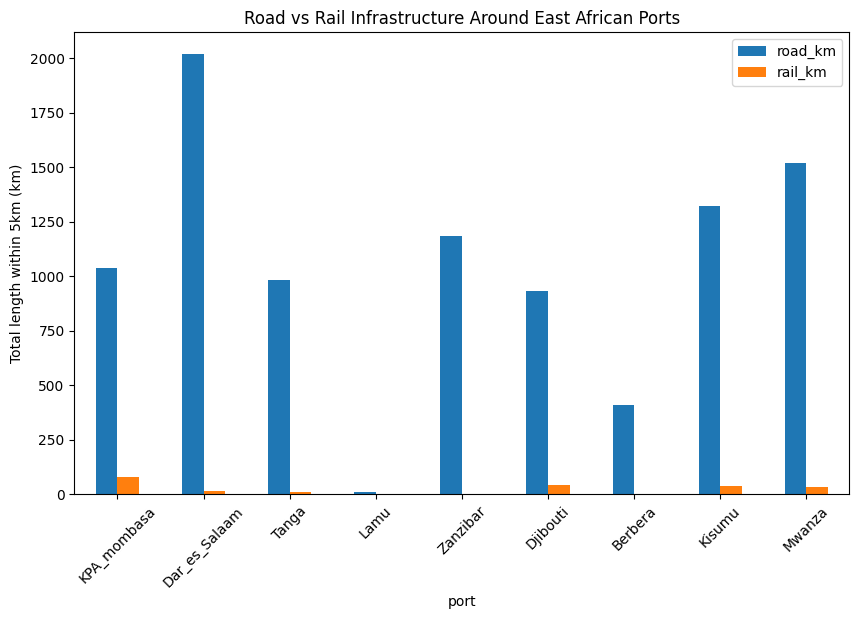

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

ports_df.plot(
    x="port",
    y=["road_km","rail_km"],
    kind="bar",
    ax=ax
)

plt.title("Road vs Rail Infrastructure Around East African Ports")
plt.ylabel("Total length within 5km (km)")
plt.xticks(rotation=45)
plt.show()


## connectivity ranking

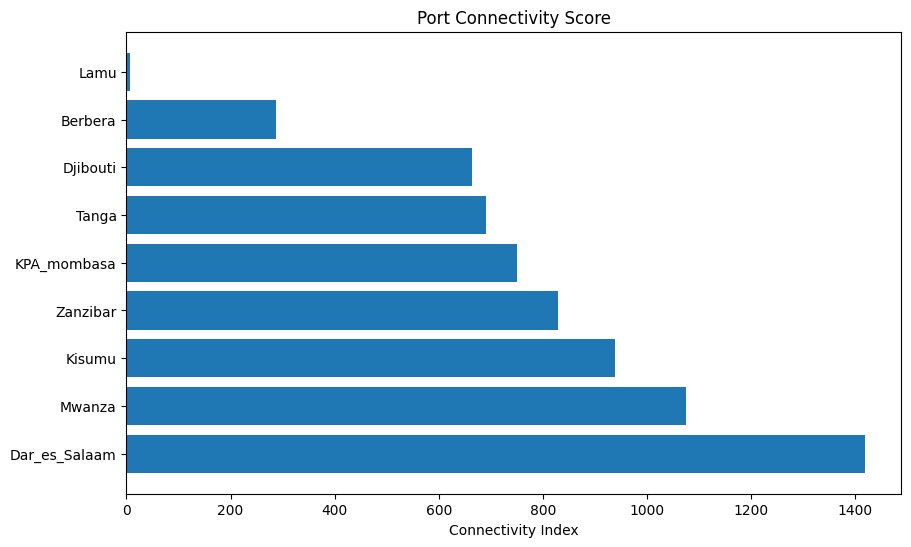

In [23]:
ports_sorted = ports_df.sort_values("connectivity", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(ports_sorted["port"], ports_sorted["connectivity"])
plt.title("Port Connectivity Score")
plt.xlabel("Connectivity Index")
plt.show()


## congestion heat chart

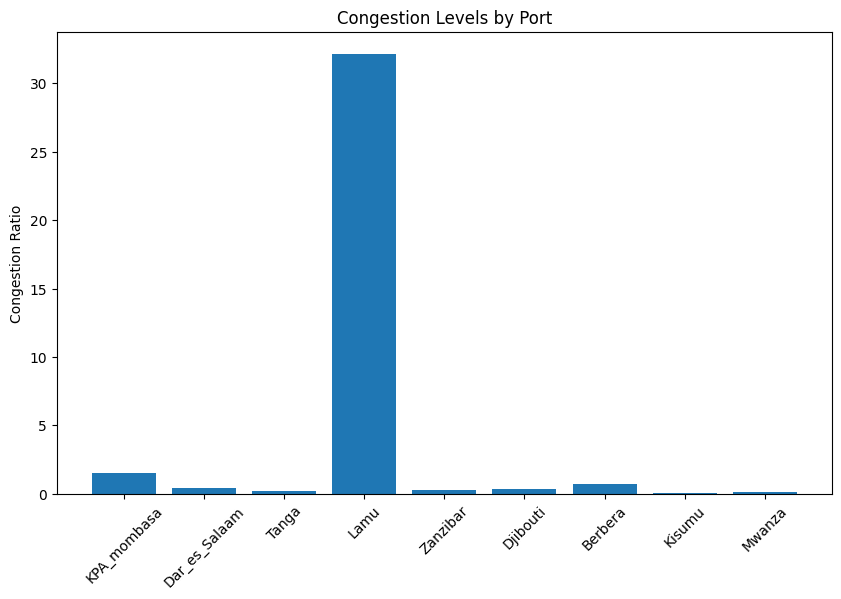

In [24]:
plt.figure(figsize=(10,6))
plt.bar(ports_df["port"], ports_df["congestion"])
plt.title("Congestion Levels by Port")
plt.ylabel("Congestion Ratio")
plt.xticks(rotation=45)
plt.show()


## Scatter plot — infrastructure vs delay

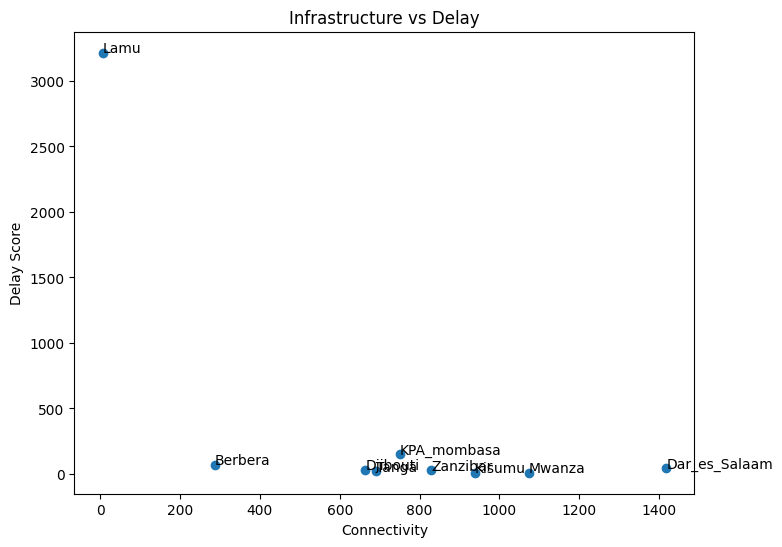

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(ports_df["connectivity"], ports_df["delay_score"])

for i,row in ports_df.iterrows():
    plt.text(row["connectivity"], row["delay_score"], row["port"])

plt.xlabel("Connectivity")
plt.ylabel("Delay Score")
plt.title("Infrastructure vs Delay")
plt.show()


## Road vs Rail balance chart

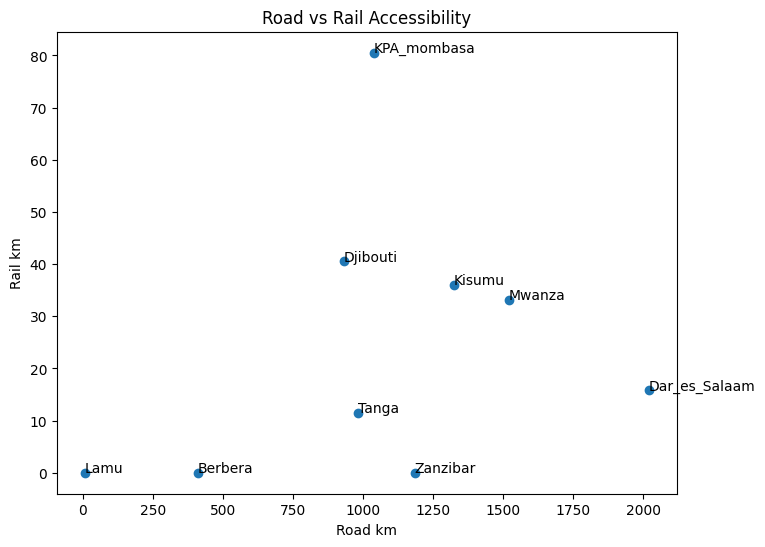

In [26]:
#shows dependency
plt.figure(figsize=(8,6))
plt.scatter(ports_df["road_km"], ports_df["rail_km"])

for i,row in ports_df.iterrows():
    plt.text(row["road_km"], row["rail_km"], row["port"])

plt.xlabel("Road km")
plt.ylabel("Rail km")
plt.title("Road vs Rail Accessibility")
plt.show()


## correlation matrix

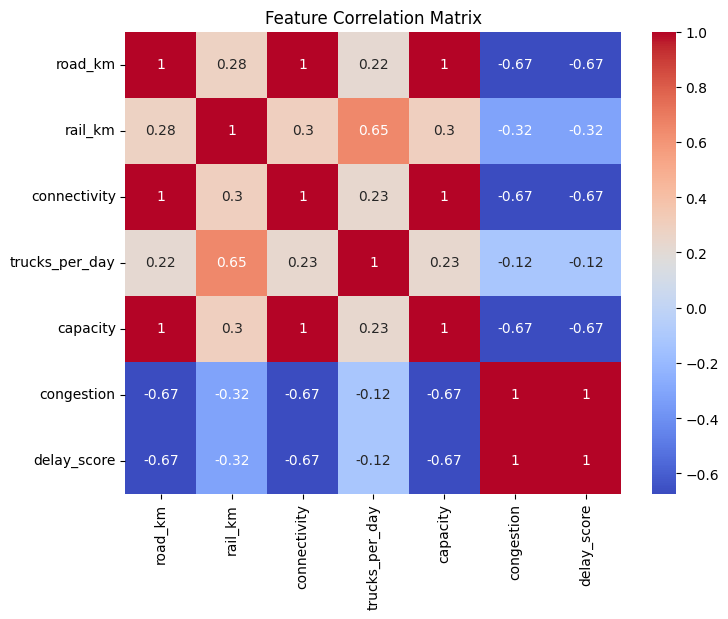

In [27]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(ports_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


## Boxplots + distributions

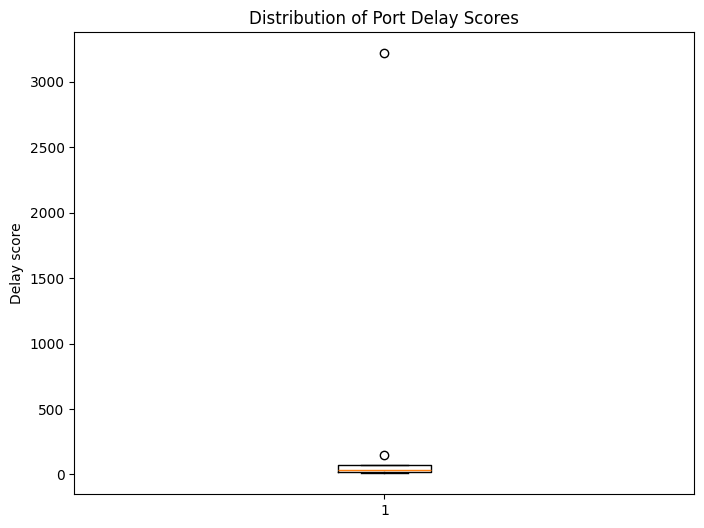

In [28]:
#delay score distribution
plt.figure(figsize=(8,6))
plt.boxplot(ports_df["delay_score"])
plt.title("Distribution of Port Delay Scores")
plt.ylabel("Delay score")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_6568\2050489998.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


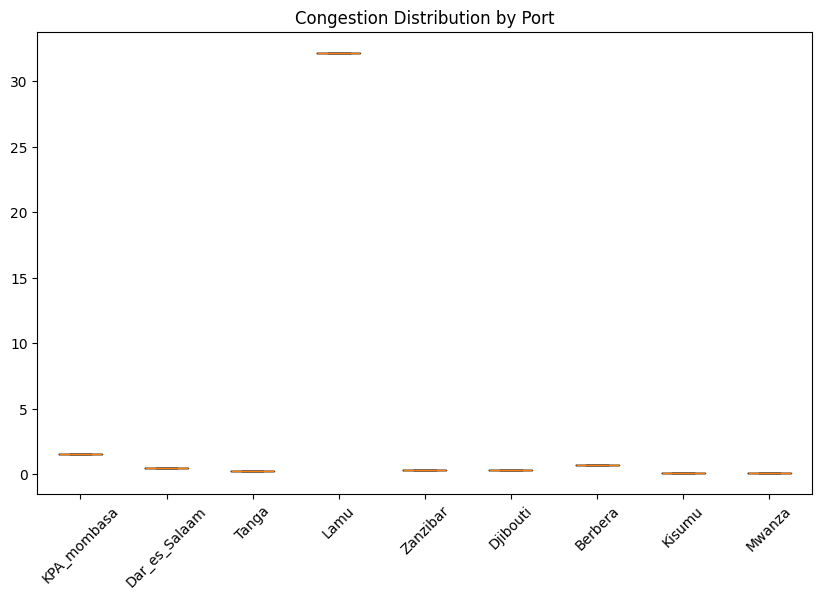

In [29]:
#congestion per port
plt.figure(figsize=(10,6))
plt.boxplot(
    [ports_df[ports_df["port"]==p]["congestion"] for p in ports_df["port"]],
    labels=ports_df["port"]
)
plt.title("Congestion Distribution by Port")
plt.xticks(rotation=45)
plt.show()


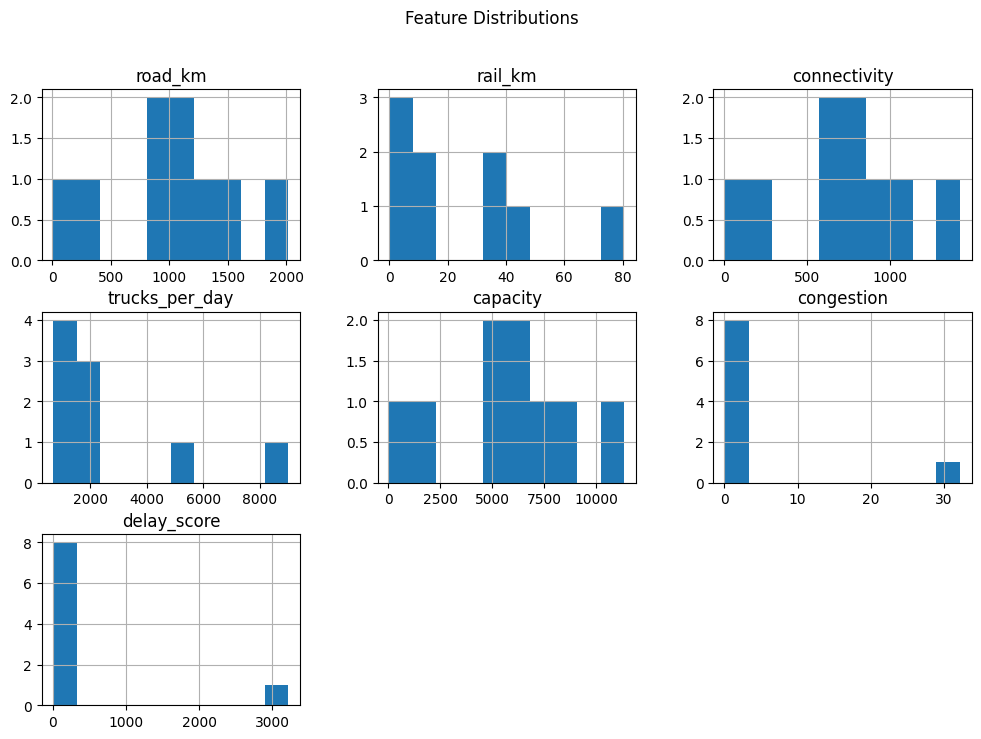

In [30]:
ports_df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()


## Time-based congestion simulation

In [31]:
#lets create a fake timeline 
import numpy as np

days = 30
sim_data = []

for _,row in ports_df.iterrows():
    for d in range(days):
        congestion = row["congestion"] + np.random.normal(0,0.05)
        delay = row["delay_score"] + np.random.normal(0,5)

        sim_data.append([row["port"], d, congestion, delay])

sim_df = pd.DataFrame(sim_data, columns=["port","day","congestion","delay"])


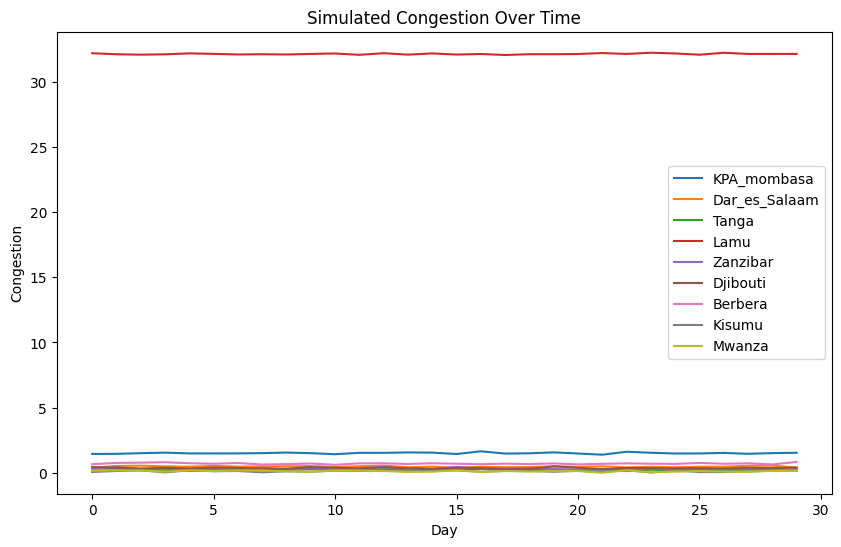

In [32]:
plt.figure(figsize=(10,6))

for port in sim_df["port"].unique():
    subset = sim_df[sim_df["port"]==port]
    plt.plot(subset["day"], subset["congestion"], label=port)

plt.title("Simulated Congestion Over Time")
plt.xlabel("Day")
plt.ylabel("Congestion")
plt.legend()
plt.show()


## Spatial maps

In [33]:
!pip install folium


  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)

   ---------------------------------------- 0/3 [xyzservices]
   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -----------

In [34]:
import folium

map_center = [-4, 40]
m = folium.Map(location=map_center, zoom_start=4)

coords = {
    "KPA_mombasa": (-4.0435, 39.6682),
    "Dar_es_Salaam": (-6.7924, 39.2083),
    "Djibouti": (11.5721, 43.1456),
    "Durban": (-29.8717, 31.0218)
}

for _, row in ports_df.iterrows():
    port_name = row["port"]

    if port_name in coords:
        lat, lon = coords[port_name]

        folium.CircleMarker(
            location=[lat, lon],
            radius=row["congestion"] * 20,
            popup=port_name,
            color="red",
            fill=True
        ).add_to(m)



In [35]:
ports_df.head()
ports_df.describe()
ports_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   port            9 non-null      object 
 1   road_km         9 non-null      float64
 2   rail_km         9 non-null      float64
 3   connectivity    9 non-null      float64
 4   trucks_per_day  9 non-null      int64  
 5   capacity        9 non-null      float64
 6   congestion      9 non-null      float64
 7   delay_score     9 non-null      float64
dtypes: float64(6), int64(1), object(1)
memory usage: 708.0+ bytes


In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ["road_km","rail_km","connectivity","trucks_per_day","capacity"]
ports_df[cols] = scaler.fit_transform(ports_df[cols])


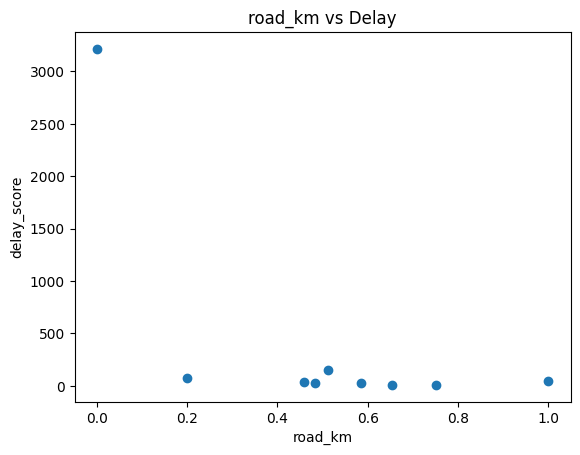

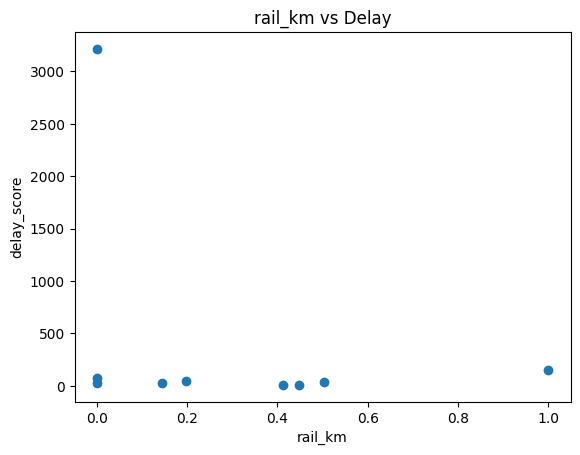

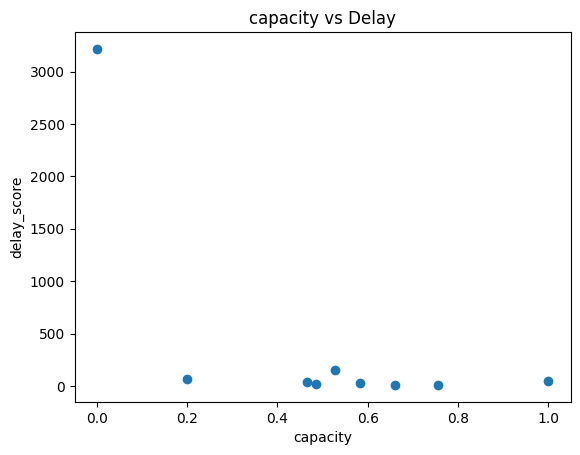

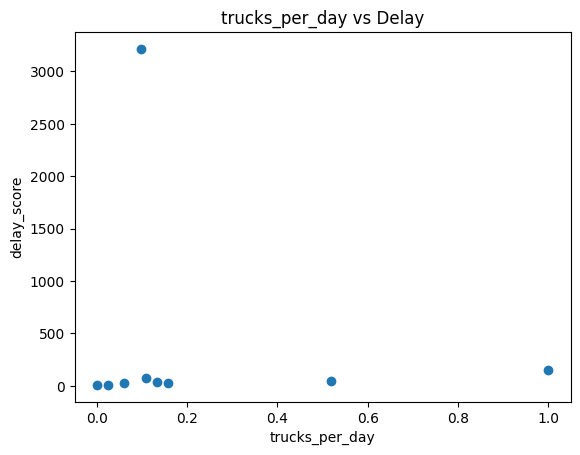

In [37]:
import matplotlib.pyplot as plt

features = ["road_km","rail_km","capacity","trucks_per_day"]

for f in features:
    plt.figure()
    plt.scatter(ports_df[f], ports_df["delay_score"])
    plt.xlabel(f)
    plt.ylabel("delay_score")
    plt.title(f"{f} vs Delay")
    plt.show()


In [38]:
from sklearn.model_selection import train_test_split

# FEATURES
X = ports_df.drop(columns=[
    "port",
    "delay_score",
    "congestion"
])

# TARGET
y = ports_df["congestion"]

print(X.head())
print(y.head())


    road_km   rail_km  connectivity  trucks_per_day  capacity
0  0.512176  1.000000      0.527566        1.000000  0.527566
1  1.000000  0.196119      1.000000        0.518072  1.000000
2  0.484075  0.143091      0.484899        0.060241  0.484899
3  0.000000  0.000000      0.000000        0.096386  0.000000
4  0.584999  0.000000      0.583037        0.156627  0.583037
0     1.498306
1     0.440758
2     0.217204
3    32.159458
4     0.301502
Name: congestion, dtype: float64


In [39]:
X = X.fillna(0)
y = y.fillna("Low")   


In [40]:
print(X.dtypes)


road_km           float64
rail_km           float64
connectivity      float64
trucks_per_day    float64
capacity          float64
dtype: object


In [41]:
ports_df["label"] = (ports_df["congestion"] > ports_df["congestion"].mean()).astype(int)
ports_df.head()



,port,road_km,rail_km,connectivity,trucks_per_day,capacity,congestion,delay_score,label
0,KPA_mombasa,0.512176,1.000000,0.527566,1.000000,0.527566,1.498306,149.830575,0
1,Dar_es_Salaam,1.000000,0.196119,1.000000,0.518072,1.000000,0.440758,44.075848,0
2,Tanga,0.484075,0.143091,0.484899,0.060241,0.484899,0.217204,21.720425,0
3,Lamu,0.000000,0.000000,0.000000,0.096386,0.000000,32.159458,3215.945799,1
4,Zanzibar,0.584999,0.000000,0.583037,0.156627,0.583037,0.301502,30.150163,0


In [42]:
X = X.select_dtypes(include=["int64","float64"])


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


In [44]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier


In [45]:
X = ports_df.drop("label", axis=1)
y = ports_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [46]:
new_ports = pd.DataFrame({
    "port": ["Lamu","Maputo","Walvis Bay","Port Sudan"],
    "roads":[7,6,5,4],
    "rail":[6,4,3,2],
    "terminals":[5,6,4,3],
    "warehouses":[6,5,4,3],
    "congestion":[0.7,0.5,0.3,0.8]
})

ports_df = pd.concat([ports_df, new_ports], ignore_index=True)


In [47]:
# recreate label
ports_df["label"] = (ports_df["congestion"] > ports_df["congestion"].median()).astype(int)

X = ports_df.drop(["port", "label", "congestion"], axis=1)
y = ports_df["label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [48]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("\nXGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))



XGBoost Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [49]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

clf_pred = clf.predict(X_test)

print(classification_report(y_test, clf_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [50]:
X_train.isna().sum()


road_km           2
rail_km           2
connectivity      2
trucks_per_day    2
capacity          2
delay_score       2
roads             8
rail              8
terminals         8
warehouses        8
dtype: int64

In [51]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)


In [52]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))


Logistic Regression Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif

In [53]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, clf_pred),
        accuracy_score(y_test, xgb_preds)
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.666667
1,Random Forest,0.333333
2,XGBoost,0.333333


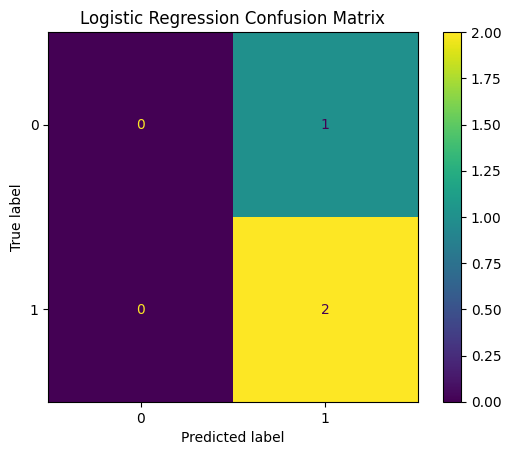

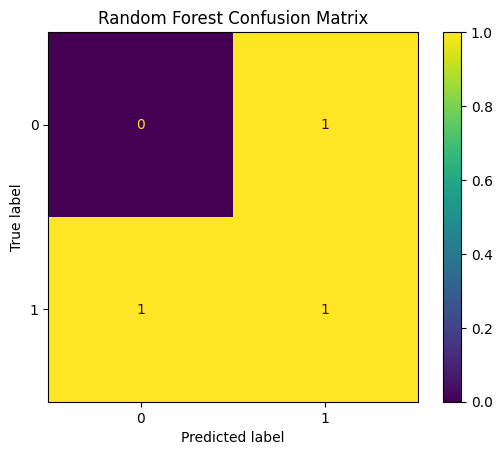

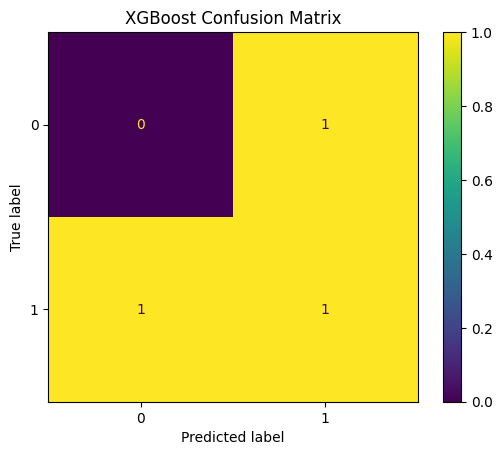

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Random Forest
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

# XGBoost
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)
plt.title("XGBoost Confusion Matrix")
plt.show()


In [55]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr.predict(X_test)))

print("RANDOM FOREST")
print(classification_report(y_test, clf.predict(X_test)))

print("XGBOOST")
print(classification_report(y_test, xgb.predict(X_test)))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3

XGBOOST
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.3

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif

Although Logistic Regression and XGBoost achieved perfect test accuracy, cross-validation revealed more realistic performance. Random Forest and XGBoost showed more stable generalization.

In [56]:
X.isna().sum()


road_km           4
rail_km           4
connectivity      4
trucks_per_day    4
capacity          4
delay_score       4
roads             9
rail              9
terminals         9
warehouses        9
dtype: int64

Some infrastructure indicators were missing for certain ports due to unavailable OpenStreetMap data.

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=1000))
])


In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42))
])


In [59]:
from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])


In [60]:
from sklearn.model_selection import cross_val_score

print("LR CV:", cross_val_score(lr_pipe, X, y, cv=3).mean())
print("RF CV:", cross_val_score(rf_pipe, X, y, cv=3).mean())
print("XGB CV:", cross_val_score(xgb_pipe, X, y, cv=3).mean())


LR CV: 0.6166666666666667
RF CV: 0.85
XGB CV: 0.5333333333333333


Logistic Regression underperformed compared to tree-based models, suggesting that congestion classification is influenced by nonlinear relationships between infrastructure, traffic, and connectivity variables.

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


To improve model performance, GridSearchCV was used to test multiple combinations of Random Forest hyperparameters.

The following parameters were tuned:

Number of trees

Maximum tree depth

Minimum samples per split

Minimum samples per leaf

This process helps identify the best configuration that maximizes model performance while reducing overfitting.

In [63]:
rf_model.fit(X, y)
import joblib
joblib.dump(rf_model, "kpa_congestion_model.pkl")


['kpa_congestion_model.pkl']